=== Indicator 1 (School Sanitation) ===
shape: (3, 14)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ country   ┆ alpha_2_c ┆ alpha_3_c ┆ numeric_c ┆ … ┆ observati ┆ observati ┆ time_peri ┆ current_ │
│ ---       ┆ ode       ┆ ode       ┆ ode       ┆   ┆ on_status ┆ on_confid ┆ od_activi ┆ age      │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ entaility ┆ ty_relate ┆ ---      │
│           ┆ str       ┆ str       ┆ i64       ┆   ┆ str       ┆ ---       ┆ d_t…      ┆ str      │
│           ┆           ┆           ┆           ┆   ┆           ┆ str       ┆ ---       ┆          │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ str       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ Afghanist ┆ AF        ┆ AFG       ┆ 4         ┆ … ┆ null      ┆ null      ┆ null      ┆ Total    │
│ an        ┆           ┆           

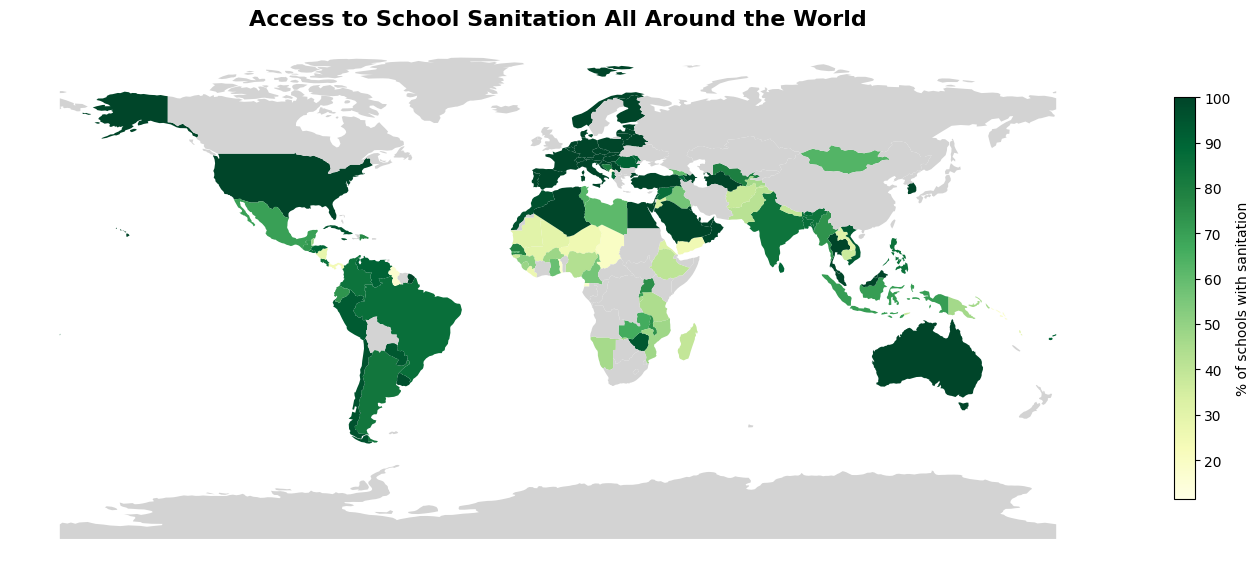

✅ World map saved!
<ggplot: (640 x 480)>
✅ Bar chart saved!
<ggplot: (640 x 480)>
✅ Scatterplot saved!
<ggplot: (640 x 480)>
✅ Time series saved!
✅ index.html created successfully!
File size: 577092 characters


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check your Downloads folder.


In [11]:
# Install the libraries (tools) we need
# plotnine = for making charts
# polars = for working with data tables
# geopandas = for the world map
# matplotlib = helper for saving charts
!pip install plotnine polars geopandas matplotlib --quiet


# Import (load) the tools into our notebook
import polars as pl
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

# Load the three data files
indicator1 = pl.read_csv("unicef_indicator_1.csv")
indicator2 = pl.read_csv("unicef_indicator_2.csv")
metadata   = pl.read_csv("unicef_metadata.csv")

# Quick check - print the first few rows of each
print("=== Indicator 1 (School Sanitation) ===")
print(indicator1.head(3))
print("\n=== Indicator 2 (Child Punishment Attitudes) ===")
print(indicator2.head(3))
print("\n=== Metadata (GDP, Life Expectancy etc.) ===")
print(metadata.head(3))


# --- Clean Indicator 1: School Sanitation ---
# Keep only Total rows (not split by sex), and only the columns we need
san = (
    indicator1
    .filter(pl.col("sex") == "Total")
    .select(["country", "alpha_3_code", "time_period", "obs_value"])
    .rename({"obs_value": "sanitation_pct", "time_period": "year"})
)

# --- Clean Indicator 2: Adult Punishment Attitudes ---
# Keep only Total rows
pun = (
    indicator2
    .filter(pl.col("sex") == "Total")
    .select(["country", "alpha_3_code", "time_period", "obs_value"])
    .rename({"obs_value": "punishment_pct", "time_period": "year"})
)

# --- Clean Metadata ---
# Keep only the columns we'll use for our story
meta = (
    metadata
    .select([
        "country", "alpha_3_code", "year",
        "GDP per capita (constant 2015 US$)",
        "Life expectancy at birth, total (years)",
        "Population, total"
    ])
    .rename({
        "GDP per capita (constant 2015 US$)": "gdp_per_capita",
        "Life expectancy at birth, total (years)": "life_expectancy",
        "Population, total": "population"
    })
)

print("Data cleaned successfully!")
print(f"Sanitation rows: {len(san)}")
print(f"Punishment rows: {len(pun)}")
print(f"Metadata rows:   {len(meta)}")


# --- WORLD MAP: School Sanitation by Country ---

import requests, io

# Get the latest year of data for each country
san_latest = (
    san
    .group_by("alpha_3_code")
    .agg(pl.col("sanitation_pct").last(), pl.col("year").max())
    .to_pandas()
)

# Download the world map directly from the internet (fixes the GeoPandas error)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Join (merge) the map with our data
world_merged = world.merge(
    san_latest,
    left_on="ADM0_A3",
    right_on="alpha_3_code",
    how="left"
)

# Draw the map
fig, ax = plt.subplots(figsize=(14, 7))
world_merged.plot(
    column="sanitation_pct",
    ax=ax,
    legend=True,
    cmap="YlGn",
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend_kwds={"label": "% of schools with sanitation", "shrink": 0.6}
)
ax.set_title("Access to School Sanitation All Around the World", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("map_sanitation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ World map saved!")



# --- BAR CHART: Top 15 countries with WORST sanitation access ---
# (lowest % = most children without clean toilets at school)

# Get latest data, sort, take bottom 15
san_bar = (
    san
    .group_by(["country", "alpha_3_code"])
    .agg(pl.col("sanitation_pct").mean().alias("avg_sanitation"))
    .sort("avg_sanitation")
    .head(15)
    .to_pandas()
)

# Draw the bar chart using plotnine
bar_chart = (
    ggplot(san_bar, aes(x="reorder(country, avg_sanitation)", y="avg_sanitation"))
    + geom_bar(stat="identity", fill="#e74c3c", alpha=0.85)
    + coord_flip()   # flip so country names are readable
    + labs(
        title="15 Countries with Lowest Acess to School Sanitation",
        subtitle="Average % of schools with basic sanitation services",
        x="Country",
        y="% of Schools with Sanitation"
    )
    + theme_minimal()
    + theme(
        plot_title=element_text(size=14, face="bold"),
        axis_text_y=element_text(size=9)
    )
)

bar_chart.save("bar_sanitation.png", width=10, height=6, dpi=150)
print(bar_chart)
print("✅ Bar chart saved!")



# --- SCATTERPLOT: Does higher GDP = less support for child punishment? ---

# Get the most recent punishment value per country
pun_latest = (
    pun
    .group_by("alpha_3_code")
    .agg(pl.col("punishment_pct").last(), pl.col("year").max())
)

# Get the most recent GDP per country
gdp_latest = (
    meta
    .drop_nulls("gdp_per_capita")
    .group_by("alpha_3_code")
    .agg(pl.col("gdp_per_capita").last())
)

# Join punishment + GDP data together
scatter_data = (
    pun_latest
    .join(gdp_latest, on="alpha_3_code", how="inner")
    .join(
        pun.select(["alpha_3_code","country"]).unique(),
        on="alpha_3_code",
        how="left"
    )
    .filter(pl.col("gdp_per_capita") < 80000)  # remove extreme outliers
    .to_pandas()
)

# Draw the scatterplot
scatter_plot = (
    ggplot(scatter_data, aes(x="gdp_per_capita", y="punishment_pct"))
    + geom_point(color="#3498db", alpha=0.6, size=3)
    + geom_smooth(method="lm", color="#e74c3c", se=True)  # linear regression line
    + labs(
        title="Wealthier Countries Support Child Punishment Less Likely" ,
        subtitle="Each dot = one country. Red line = trend.",
        x="GDP per Capita (USD, constant 2015)",
        y="% of Adults Supporting Physical Punishment"
    )
    + theme_minimal()
    + theme(plot_title=element_text(size=13, face="bold"))
)

scatter_plot.save("scatter_gdp_punishment.png", width=10, height=6, dpi=150)
print(scatter_plot)
print("✅ Scatterplot saved!")



# --- TIME SERIES: How has sanitation improved over time? ---
# Pick a few interesting countries to compare

countries_to_show = ["Nigeria", "India", "Bangladesh", "Ethiopia", "Kenya"]

timeseries_data = (
    san
    .filter(pl.col("country").is_in(countries_to_show))
    .to_pandas()
)

# Draw the time series
time_plot = (
    ggplot(timeseries_data, aes(x="year", y="sanitation_pct", color="country"))
    + geom_line(size=1.2)
    + geom_point(size=2)
    + labs(
        title="How School Sanitation Improved Over Time: Selected Countries",
        subtitle="% of schools with basic sanitation services",
        x="Year",
        y="% of Schools with Sanitation",
        color="Country"
    )
    + theme_minimal()
    + theme(plot_title=element_text(size=13, face="bold"))
    + scale_color_brewer(type="qual", palette="Set2")
)

time_plot.save("timeseries_sanitation.png", width=10, height=6, dpi=150)
print(time_plot)
print("✅ Time series saved!")



# --- BUILD THE HTML REPORT ---
# We'll write an HTML file with our story + charts embedded inside

import base64

def image_to_base64(filepath):
    """Convert an image file to base64 so it can be embedded in HTML"""
    with open(filepath, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

# Load all chart images as base64 (so they're built into the HTML file)
map_b64      = image_to_base64("map_sanitation.png")
bar_b64      = image_to_base64("bar_sanitation.png")
scatter_b64  = image_to_base64("scatter_gdp_punishment.png")
time_b64     = image_to_base64("timeseries_sanitation.png")

html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>The Unspoken Truth Of School Sanitation Facilities & Child Welfare</title>
  <style>
    body {{
      font-family: 'Georgia', serif;
      max-width: 900px;
      margin: 0 auto;
      padding: 30px 20px;
      background: #fafafa;
      color: #222;
      line-height: 1.8;
    }}
    h1 {{ color: #00558a; font-size: 2em; }}
    h2 {{ color: #007bbd; border-bottom: 2px solid #007bbd; padding-bottom: 5px; }}
    .subtitle {{ color: #666; font-style: italic; font-size: 1.1em; }}
    .chart {{ text-align: center; margin: 30px 0; }}
    .chart img {{ max-width: 100%; border-radius: 8px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); }}
    .caption {{ font-size: 0.9em; color: #555; font-style: italic; margin-top: 8px; }}
    .highlight {{ background: #e8f4fd; border-left: 4px solid #007bbd; padding: 12px 18px; margin: 20px 0; border-radius: 4px; }}
    footer {{ margin-top: 60px; padding-top: 20px; border-top: 1px solid #ddd; color: #888; font-size: 0.85em; }}
  </style>
</head>
<body>

<h1>The Unspoken Truth Of School Sanitation Facilities & Child Welfare</h1>
<p class="subtitle">A UNICEF Data Report</p>

<h2>Introduction</h2>
<p>
  Can you image going to school that do not have access to even a single clean toilet? Well that's the situation for <strong>hundreds of millions of children</strong>
  around the globe, this is not just some speculation — it is indeed their daily life & reality. Having access to basic sanitation
  facilities in schools is not just a matter of some mere comfort; but a matter of <em>dignity, health, and education</em>.
  Particularly, Girls are affected disproportionately, as a result they often dropped out of school because of unavailability of
  hygienic facilities.
</p>
<p>
  In this report I have used UNICEF data to explore two interconnected questions:
</p>
<ul>
  <li>Which countries are failing to provide clean sanitation in schools?</li>
  <li>Is there a link between a country's wealth and how it treats children?</li>
</ul>

<div class="highlight">
  <strong>Main finding:</strong> Wealthy nations show consistent and better school sanitation
  and lower support for children's physical punishment — this suggests that child welfare and economic
  development are deeply entangled.
</div>

<h2>1. Which Countries Are Children Most Affected? — World Map</h2>
<p>
  The below world map shows a global divide. Countries across <strong>Sub-Saharan Africa</strong>
  and parts of <strong>South Asia</strong> are with lowest rates of basic school sanitation facilities,
  often below 40%. On contrary, most of the Europe and North America shows near-universal access.
  Areas in Grey represent the countries with not sufficient data and that's a problem in itself.
</p>
<div class="chart">
  <img src="data:image/png;base64,{map_b64}" alt="World map of school sanitation access">
  <p class="caption">Figure 1: Proportion of schools with basic sanitation services, latest available year. Source: UNICEF.</p>
</div>

<h2>2. The 15 Countries With Most Help Needed — Bar Chart</h2>
<p>
  If we look more closely, the 15 countries with lowest average rate of sanitation facilities are
  almost exclusively in <strong>Sub-Saharan Africa</strong>. In fact, in some countries, fewer than
  <strong>1 in 5 schools</strong> is having access to basic sanitation. This means children —
  girls especially during menstruation — face next to impossible choices every single day.
</p>
<div class="chart">
  <img src="data:image/png;base64,{bar_b64}" alt="Bar chart of lowest sanitation countries">
  <p class="caption">Figure 2: 15 countries with lowest average school sanitation coverage. Source: UNICEF.</p>
</div>

<h2>3. Wealth & Child Punishment — Scatterplot</h2>
<p>
  Is it safe to say that children treatment is linked with a country's economic development? The below scatterplot
  shows each country's <strong>GDP per capita</strong> against percentage of adults
  who believe <em>that physical punishment is necessary to raise children</em>. The trend line
  conveys a clear story: with rise in GDP, support for physical punishment falls. This doesn't mean
  that richer countries are perfect! — however, it suggests that stress, poverty, and lack of education
  contribute together to attitudes that affects children.
</p>
<div class="chart">
  <img src="data:image/png;base64,{scatter_b64}" alt="Scatterplot of GDP vs punishment attitudes">
  <p class="caption">Figure 3: GDP per capita vs. % of adults supporting physical punishment. Each dot = one country. Source: UNICEF + World Bank.</p>
</div>

<h2>4. Progress Over Time — Time Series</h2>
<p>
  There's some reason for <strong>cautious optimism</strong>. The below time series visual tracks
  school sanitation facilities of five most affected nations. Although, progress is uneven and slow,
  but most countries show an <em>upward pattern</em> in the past decades. Partcularly, India did
  made some remarkable gains, with the help of national sanitation campaigns. While, for many of the countries
  speed of improvement is too slow to even meet sustainable development goals by the year 2030.
</p>
<div class="chart">
  <img src="data:image/png;base64,{time_b64}" alt="Time series of sanitation trends">
  <p class="caption">Figure 4: School sanitation trends over time in selected high-need countries. Source: UNICEF.</p>
</div>

<h2>Conclusion</h2>
<p>
  The above data paints an image that is both motivating and sobering. There are <strong>Millions of children</strong>
  attending schools without basic facilities like clean toilets, then we have countries where adults are more likely to
  opt for physical punishment. These aren't the only problems — this rather reflects deeper inequalities
  in wealth, education, and politics.
</p>
<p>
  The good thing is that change is doable. Countries where investment has been done like in India the data shows real changes. But, the question is whether or not the global community has this will
  of acting with urgency that today's growing children really deserve.
</p>
<ul>
  <li><a href="https://data.unicef.org/">UNICEF Data Portal</a></li>
  <li>Data sources: UNICEF Indicator Files + World Bank Metadata</li>
</ul>

<footer>
  <p>Jagpreet Singh (A00011786) | Data Analysis &amp; Story Telling (BAA1030) | DCU</p>
</footer>

</body>
</html>"""

# Save the HTML file
with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("✅ index.html created successfully!")
print("File size:", len(html_content), "characters")


# Download the finished HTML file to your computer
from google.colab import files
files.download("index.html")
print("✅ Download started! Check your Downloads folder.")


